# AAPL

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn import datasets, metrics
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

# Defer TensorFlow and CUDA setup to the training cells so the notebook kernel can connect faster.
path_to_data = '../pre-processing/'

def load_data(file_name, columns=None):
    if columns is None:
        return pd.read_csv(path_to_data + file_name)
    return pd.read_csv(path_to_data + file_name, usecols=columns)
load_data('AAPL_final.csv', columns=['body_clean', 'entities']).head()

,entities,body_clean
0,-1,$aapl couldn’t break ath
1,-1,$aapl big profit taking next day
2,-1,$aapl can’t wait see permabulls take aapl $10b...
3,-1,$aapl propped 500 billion injected market........
4,-1,$aapl happy economy crash 2020 ....hate realist


In [2]:
dataset = load_data('aapl_final.csv', columns=['body_clean', 'entities'])

# Drop rows with no explicit sentiment tag (entities == 0 means user didn't tag/neutral)
dataset = dataset[dataset['entities'] != 0].copy()

# Binary: -1 (bearish) -> 0, 1 (bullish) -> 1
y_all = (dataset['entities'].values == 1).astype(int)

X_train_text, X_val_text, y_train, y_val = train_test_split(
    dataset['body_clean'].values,
    y_all,
    test_size=0.2,
    random_state=2,
    stratify=y_all
)

features = FeatureUnion([
    ('word', TfidfVectorizer(analyzer='word', ngram_range=(1,2), min_df=2,
                             max_df=0.95, sublinear_tf=True, max_features=200_000)),
    ('char', TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), min_df=2,
                             max_df=0.95, sublinear_tf=True, max_features=200_000)),
])

X_train = features.fit_transform(X_train_text)
X_val   = features.transform(X_val_text)

In [3]:
model = LogisticRegression(random_state=42, max_iter=2000, C=3.0, penalty='l2', solver='liblinear')
history = model.fit(X_train, y_train)

In [4]:
y_pred = model.predict(X_val)
print('Model accuracy score: {0:0.4f}'.format(accuracy_score(y_val, y_pred)))

Model accuracy score: 0.8892


In [5]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix, classification_report,
    balanced_accuracy_score, f1_score
)

proba = model.predict_proba(X_val)
y_pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_val, y_pred))
print(confusion_matrix(y_val, y_pred, labels=[0, 1]))
print(classification_report(y_val, y_pred, digits=4))

Accuracy: 0.8892186925058261
Balanced accuracy: 0.8885209601110953
[[51020  9031]
 [ 4517 57727]]
              precision    recall  f1-score   support

           0     0.9187    0.8496    0.8828     60051
           1     0.8647    0.9274    0.8950     62244

    accuracy                         0.8892    122295
   macro avg     0.8917    0.8885    0.8889    122295
weighted avg     0.8912    0.8892    0.8890    122295



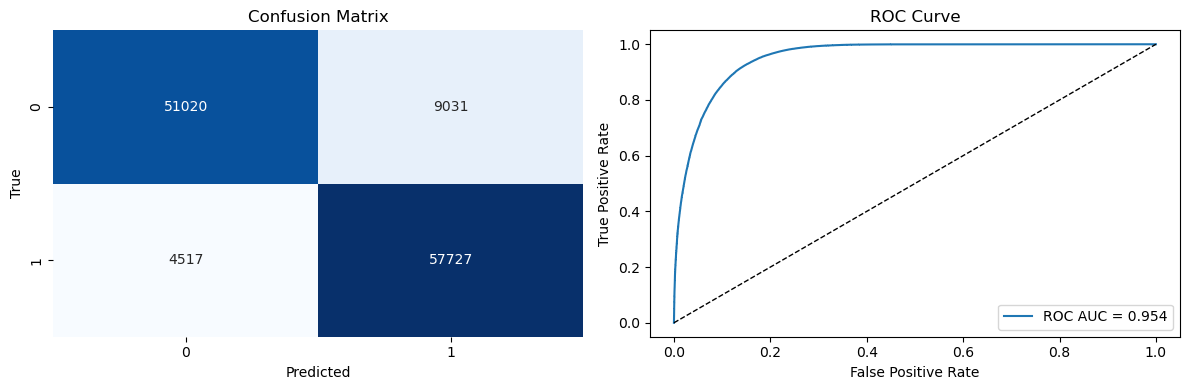

In [6]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

# scikit-learn LogisticRegression does not return a Keras-like `history` object.
# Plot evaluation curves based on predictions instead.
y_pred = model.predict(X_val)
proba1 = model.predict_proba(X_val)[:, 1]  # P(class 1)

cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
fpr, tpr, _ = roc_curve(y_val, proba1, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=[0, 1], yticklabels=[0, 1]
 )
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.tight_layout()
plt.show()

# AMZN

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn import datasets, metrics
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

# Defer TensorFlow and CUDA setup to the training cells so the notebook kernel can connect faster.
path_to_data = '../pre-processing/'

def load_data(file_name, columns=None):
    if columns is None:
        return pd.read_csv(path_to_data + file_name)
    return pd.read_csv(path_to_data + file_name, usecols=columns)
load_data('AMZN_final.csv', columns=['body_clean', 'entities']).head()

,entities,body_clean
0,-1,$amzn waiting bought back short higher price.
1,-1,$spy $fb $amzn $googl $aapl sorry bulls time s...
2,-1,$fb $googl $amzn one-day event. doj anti-trust...
3,-1,$spy $fb $amzn $googl $aapl looking go short j...
4,-1,$amzn timed people (2days tech earnings.. dont...


In [8]:
dataset = load_data('amzn_final.csv', columns=['body_clean', 'entities'])

# Clean inputs: make sure we don't feed NaN/non-strings to TF-IDF
dataset['entities'] = pd.to_numeric(dataset['entities'], errors='coerce')
dataset = dataset.dropna(subset=['entities', 'body_clean']).copy()
dataset['body_clean'] = dataset['body_clean'].astype(str)

# Drop rows with no explicit sentiment tag (entities == 0 means user didn't tag/neutral)
dataset = dataset[dataset['entities'] != 0].copy()

# Binary: -1 (bearish) -> 0, 1 (bullish) -> 1
y_all = (dataset['entities'].values == 1).astype(int)

X_train_text, X_val_text, y_train, y_val = train_test_split(
    dataset['body_clean'].values,
    y_all,
    test_size=0.2,
    random_state=2,
    stratify=y_all
)

features = FeatureUnion([
    ('word', TfidfVectorizer(analyzer='word', ngram_range=(1,2), min_df=2,
                             max_df=0.95, sublinear_tf=True, max_features=200_000)),
    ('char', TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), min_df=2,
                             max_df=0.95, sublinear_tf=True, max_features=200_000)),
])

X_train = features.fit_transform(X_train_text)
X_val   = features.transform(X_val_text)

In [9]:
model = LogisticRegression(random_state=42, max_iter=2000, C=3.0, penalty='l2', solver='liblinear')
history = model.fit(X_train, y_train)

In [10]:
y_pred = model.predict(X_val)
print('Model accuracy score: {0:0.4f}'.format(accuracy_score(y_val, y_pred)))

Model accuracy score: 0.8962


In [11]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix, classification_report,
    balanced_accuracy_score, f1_score
)

proba = model.predict_proba(X_val)
y_pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_val, y_pred))
print(confusion_matrix(y_val, y_pred, labels=[0, 1]))
print(classification_report(y_val, y_pred, digits=4))

Accuracy: 0.8962201247610722
Balanced accuracy: 0.8952376143956953
[[28220  4557]
 [ 2447 32265]]
              precision    recall  f1-score   support

           0     0.9202    0.8610    0.8896     32777
           1     0.8762    0.9295    0.9021     34712

    accuracy                         0.8962     67489
   macro avg     0.8982    0.8952    0.8958     67489
weighted avg     0.8976    0.8962    0.8960     67489



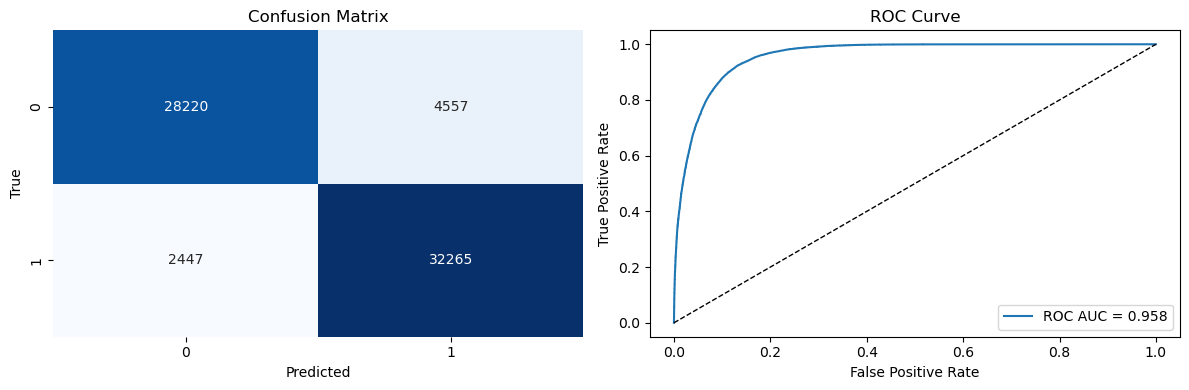

In [12]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

y_pred = model.predict(X_val)
proba1 = model.predict_proba(X_val)[:, 1]  # P(class 1)

cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
fpr, tpr, _ = roc_curve(y_val, proba1, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=[0, 1], yticklabels=[0, 1]
 )
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.tight_layout()
plt.show()

# FB

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn import datasets, metrics
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

# Defer TensorFlow and CUDA setup to the training cells so the notebook kernel can connect faster.
path_to_data = '../pre-processing/'

def load_data(file_name, columns=None):
    if columns is None:
        return pd.read_csv(path_to_data + file_name)
    return pd.read_csv(path_to_data + file_name, usecols=columns)
load_data('FB_final.csv', columns=['body_clean', 'entities']).head()

,entities,body_clean
0,-1,$fb life support. expect massive drop soon.
1,-1,$fb shorting trash meta dead. competition disa...
2,-1,one buying garbage lmaooo
3,-1,"total loss. shorted $fb, can't believe it’s bad."
4,-1,one company. crash.


In [14]:
dataset = load_data('fb_final.csv', columns=['body_clean', 'entities'])

# Clean inputs: make sure we don't feed NaN/non-strings to TF-IDF
dataset['entities'] = pd.to_numeric(dataset['entities'], errors='coerce')
dataset = dataset.dropna(subset=['entities', 'body_clean']).copy()
dataset['body_clean'] = dataset['body_clean'].astype(str)

# Drop rows with no explicit sentiment tag (entities == 0 means user didn't tag/neutral)
dataset = dataset[dataset['entities'] != 0].copy()

# Binary: -1 (bearish) -> 0, 1 (bullish) -> 1
y_all = (dataset['entities'].values == 1).astype(int)

X_train_text, X_val_text, y_train, y_val = train_test_split(
    dataset['body_clean'].values,
    y_all,
    test_size=0.2,
    random_state=2,
    stratify=y_all
)

features = FeatureUnion([
    ('word', TfidfVectorizer(analyzer='word', ngram_range=(1,2), min_df=2,
                             max_df=0.95, sublinear_tf=True, max_features=200_000)),
    ('char', TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), min_df=2,
                             max_df=0.95, sublinear_tf=True, max_features=200_000)),
])

X_train = features.fit_transform(X_train_text)
X_val   = features.transform(X_val_text)

In [15]:
model = LogisticRegression(random_state=42, max_iter=2000, C=3.0, penalty='l2', solver='liblinear')
history = model.fit(X_train, y_train)

In [16]:
y_pred = model.predict(X_val)
print('Model accuracy score: {0:0.4f}'.format(accuracy_score(y_val, y_pred)))

Model accuracy score: 0.9040


In [17]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix, classification_report,
    balanced_accuracy_score, f1_score
)

proba = model.predict_proba(X_val)
y_pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_val, y_pred))
print(confusion_matrix(y_val, y_pred, labels=[0, 1]))
print(classification_report(y_val, y_pred, digits=4))

Accuracy: 0.904022821777391
Balanced accuracy: 0.9036217951851189
[[17741  2712]
 [ 1258 19653]]
              precision    recall  f1-score   support

           0     0.9338    0.8674    0.8994     20453
           1     0.8787    0.9398    0.9083     20911

    accuracy                         0.9040     41364
   macro avg     0.9063    0.9036    0.9038     41364
weighted avg     0.9060    0.9040    0.9039     41364



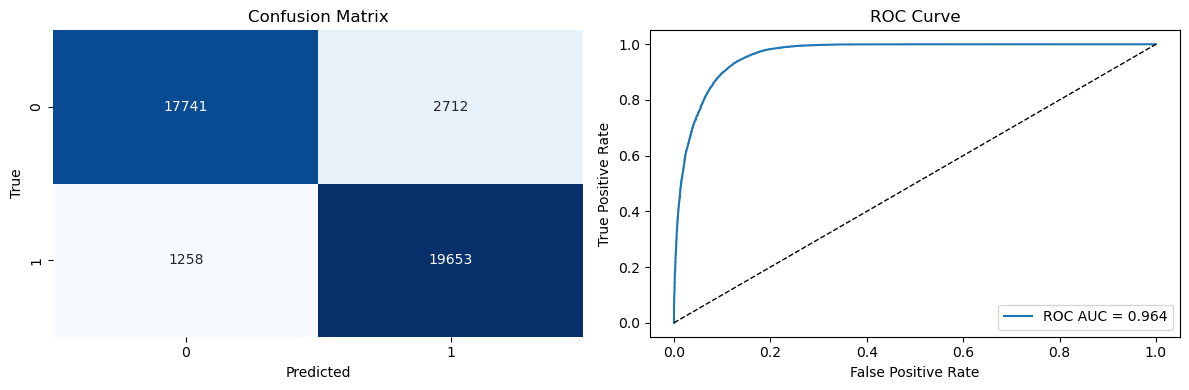

In [18]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

y_pred = model.predict(X_val)
proba1 = model.predict_proba(X_val)[:, 1]  # P(class 1)

cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
fpr, tpr, _ = roc_curve(y_val, proba1, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=[0, 1], yticklabels=[0, 1]
 )
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.tight_layout()
plt.show()

# NVDA

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn import datasets, metrics
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

# Defer TensorFlow and CUDA setup to the training cells so the notebook kernel can connect faster.
path_to_data = '../pre-processing/'

def load_data(file_name, columns=None):
    if columns is None:
        return pd.read_csv(path_to_data + file_name)
    return pd.read_csv(path_to_data + file_name, usecols=columns)
load_data('NVDA_final.csv', columns=['body_clean', 'entities']).head()

,entities,body_clean
0,-1,$nvda bad news priced in? lol who’s believing ...
1,-1,"going dump hard. $nvda, $aapl, $msft: garbage ..."
2,-1,"$nvda gone zero hero, going back zero."
3,-1,$nvda going down. disaster waiting happen.
4,-1,nasdaq 150 points today. another 200-250 tomor...


In [20]:
dataset = load_data('nvda_final.csv', columns=['body_clean', 'entities'])

# Clean inputs: make sure we don't feed NaN/non-strings to TF-IDF
dataset['entities'] = pd.to_numeric(dataset['entities'], errors='coerce')
dataset = dataset.dropna(subset=['entities', 'body_clean']).copy()
dataset['body_clean'] = dataset['body_clean'].astype(str)

# Drop rows with no explicit sentiment tag (entities == 0 means user didn't tag/neutral)
dataset = dataset[dataset['entities'] != 0].copy()

# Binary: -1 (bearish) -> 0, 1 (bullish) -> 1
y_all = (dataset['entities'].values == 1).astype(int)

X_train_text, X_val_text, y_train, y_val = train_test_split(
    dataset['body_clean'].values,
    y_all,
    test_size=0.2,
    random_state=2,
    stratify=y_all
)

features = FeatureUnion([
    ('word', TfidfVectorizer(analyzer='word', ngram_range=(1,2), min_df=2,
                             max_df=0.95, sublinear_tf=True, max_features=200_000)),
    ('char', TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), min_df=2,
                             max_df=0.95, sublinear_tf=True, max_features=200_000)),
])

X_train = features.fit_transform(X_train_text)
X_val   = features.transform(X_val_text)

In [21]:
model = LogisticRegression(random_state=42, max_iter=2000, C=3.0, penalty='l2', solver='liblinear')
history = model.fit(X_train, y_train)

In [22]:
y_pred = model.predict(X_val)
print('Model accuracy score: {0:0.4f}'.format(accuracy_score(y_val, y_pred)))

Model accuracy score: 0.9179


In [23]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix, classification_report,
    balanced_accuracy_score, f1_score
)

proba = model.predict_proba(X_val)
y_pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_val, y_pred))
print(confusion_matrix(y_val, y_pred, labels=[0, 1]))
print(classification_report(y_val, y_pred, digits=4))

Accuracy: 0.9178561534984764
Balanced accuracy: 0.9173214037753574
[[29741  4064]
 [ 1570 33212]]
              precision    recall  f1-score   support

           0     0.9499    0.8798    0.9135     33805
           1     0.8910    0.9549    0.9218     34782

    accuracy                         0.9179     68587
   macro avg     0.9204    0.9173    0.9176     68587
weighted avg     0.9200    0.9179    0.9177     68587



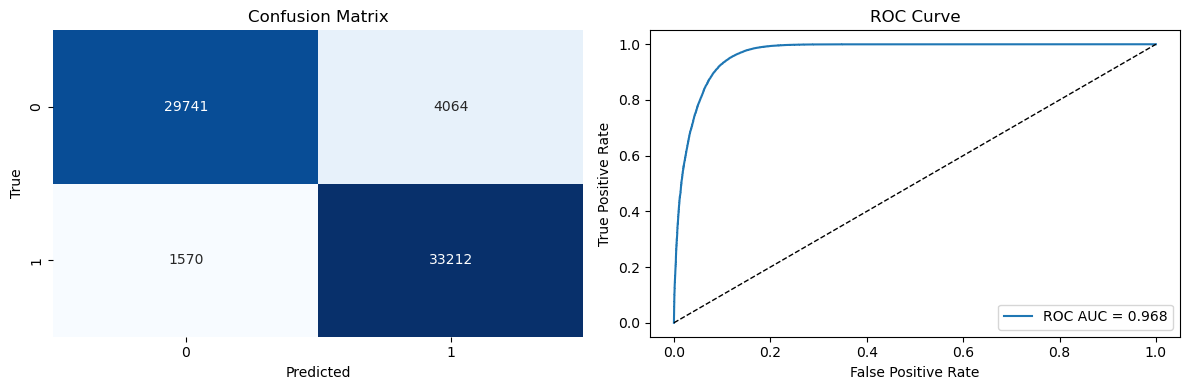

In [24]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

y_pred = model.predict(X_val)
proba1 = model.predict_proba(X_val)[:, 1]  # P(class 1)

cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
fpr, tpr, _ = roc_curve(y_val, proba1, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=[0, 1], yticklabels=[0, 1]
 )
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.tight_layout()
plt.show()

# TSLA

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn import datasets, metrics
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

# Defer TensorFlow and CUDA setup to the training cells so the notebook kernel can connect faster.
path_to_data = '../pre-processing/'

def load_data(file_name, columns=None):
    if columns is None:
        return pd.read_csv(path_to_data + file_name)
    return pd.read_csv(path_to_data + file_name, usecols=columns)
load_data('TSLA_final.csv', columns=['body_clean', 'entities']).head()

,entities,body_clean
0,-1,$tsla painful holding puts xmas hold tight bea...
1,-1,$tsla short it.
2,-1,$tsla thursday short attack open like today le...
3,-1,$tsla bulls delirious maybe rightfully so. how...
4,-1,$tsla last party.


In [26]:
dataset = load_data('tsla_final.csv', columns=['body_clean', 'entities'])

# Clean inputs: make sure we don't feed NaN/non-strings to TF-IDF
dataset['entities'] = pd.to_numeric(dataset['entities'], errors='coerce')
dataset = dataset.dropna(subset=['entities', 'body_clean']).copy()
dataset['body_clean'] = dataset['body_clean'].astype(str)

# Drop rows with no explicit sentiment tag (entities == 0 means user didn't tag/neutral)
dataset = dataset[dataset['entities'] != 0].copy()

# Binary: -1 (bearish) -> 0, 1 (bullish) -> 1
y_all = (dataset['entities'].values == 1).astype(int)

X_train_text, X_val_text, y_train, y_val = train_test_split(
    dataset['body_clean'].values,
    y_all,
    test_size=0.2,
    random_state=2,
    stratify=y_all
)

features = FeatureUnion([
    ('word', TfidfVectorizer(analyzer='word', ngram_range=(1,2), min_df=2,
                             max_df=0.95, sublinear_tf=True, max_features=200_000)),
    ('char', TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), min_df=2,
                             max_df=0.95, sublinear_tf=True, max_features=200_000)),
])

X_train = features.fit_transform(X_train_text)
X_val   = features.transform(X_val_text)

In [27]:
model = LogisticRegression(random_state=42, max_iter=2000, C=3.0, penalty='l2', solver='liblinear')
history = model.fit(X_train, y_train)

In [28]:
y_pred = model.predict(X_val)
print('Model accuracy score: {0:0.4f}'.format(accuracy_score(y_val, y_pred)))

Model accuracy score: 0.8430


In [29]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix, classification_report,
    balanced_accuracy_score, f1_score
)

proba = model.predict_proba(X_val)
y_pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_val, y_pred))
print(confusion_matrix(y_val, y_pred, labels=[0, 1]))
print(classification_report(y_val, y_pred, digits=4))

Accuracy: 0.8430037989584993
Balanced accuracy: 0.8429572016317171
[[78861 18256]
 [12284 85126]]
              precision    recall  f1-score   support

           0     0.8652    0.8120    0.8378     97117
           1     0.8234    0.8739    0.8479     97410

    accuracy                         0.8430    194527
   macro avg     0.8443    0.8430    0.8428    194527
weighted avg     0.8443    0.8430    0.8428    194527



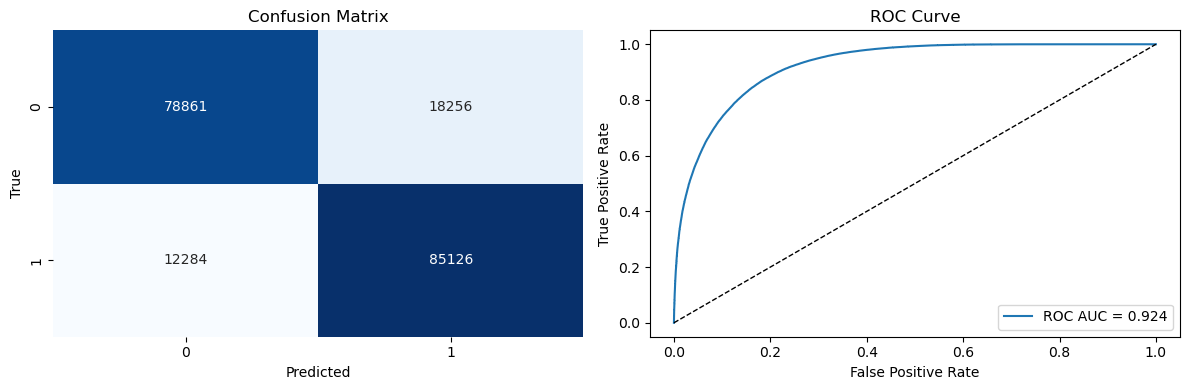

In [30]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

y_pred = model.predict(X_val)
proba1 = model.predict_proba(X_val)[:, 1]  # P(class 1)

cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
fpr, tpr, _ = roc_curve(y_val, proba1, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=[0, 1], yticklabels=[0, 1]
 )
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.tight_layout()
plt.show()